# **Install Dependencies**

In [122]:
!pip install -q torch torchvision torchaudio
!pip install -q torch-geometric
!pip install -q pandas numpy scikit-learn matplotlib seaborn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.0 MB/s eta 0:00:00


# **Imports**

In [151]:
import numpy as np
import pandas as pd
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from tqdm import tqdm

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

torch.manual_seed(42)
np.random.seed(42)

print(device)

cuda


# **Load METR-LA Dataset**

In [124]:
CSV_PATH = "/content/METR-LA.csv"
ADJ_PATH = "/content/adj_mx_METR-LA.pkl"

df = pd.read_csv(CSV_PATH)

timestamps = pd.to_datetime(df.iloc[:,0])

traffic = df.iloc[:,1:].values.astype(np.float32)

print("Traffic shape:", traffic.shape)

Traffic shape: (34272, 207)


# **Load Adjacency Matrix**

In [125]:
with open(ADJ_PATH,'rb') as f:
    sensor_ids, sensor_map, adj_mx = pickle.load(
        f,
        encoding='latin1'
    )

adj_mx = np.array(adj_mx)

print(adj_mx.shape)

(207, 207)


# **Missing Value Treatment**

In [126]:
traffic[traffic == 0] = np.nan
traffic = pd.DataFrame(traffic)
traffic = traffic.interpolate(
    method='linear',
    axis=0
)
traffic = traffic.fillna(
    method='bfill'
)
traffic = traffic.fillna(
    method='ffill'
)
traffic = traffic.values

# **Exploratory Data Analysis**

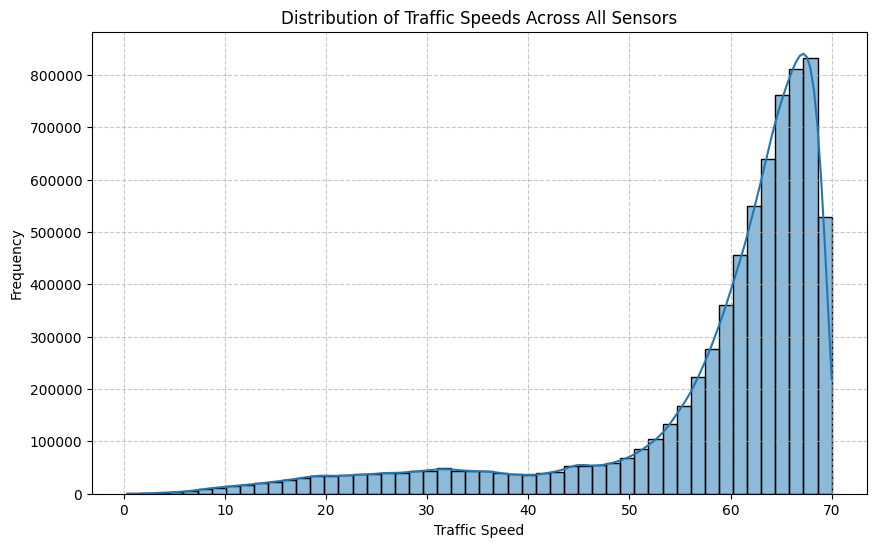

In [160]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(traffic.flatten(), kde=True, bins=50)
plt.title('Distribution of Traffic Speeds Across All Sensors')
plt.xlabel('Traffic Speed')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# **Traffic Speed Over Time for Selected Sensors**

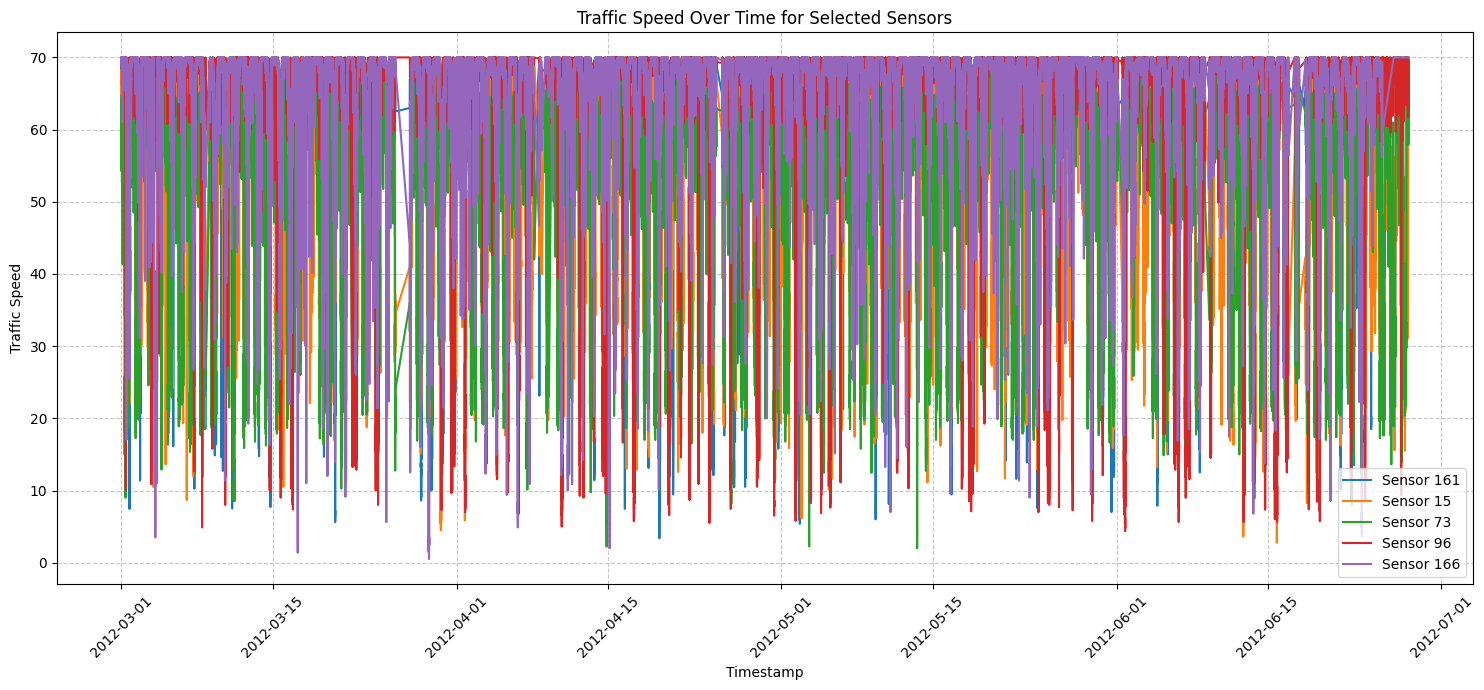

In [161]:
plt.figure(figsize=(15, 7))
num_sensors_to_plot = 5
np.random.seed(42)
sensor_indices = np.random.choice(traffic.shape[1], num_sensors_to_plot, replace=False)
for i, sensor_idx in enumerate(sensor_indices):
    plt.plot(timestamps, traffic[:, sensor_idx], label=f'Sensor {sensor_idx}')
plt.title('Traffic Speed Over Time for Selected Sensors')
plt.xlabel('Timestamp')
plt.ylabel('Traffic Speed')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Sensor Correlation Heatmap**


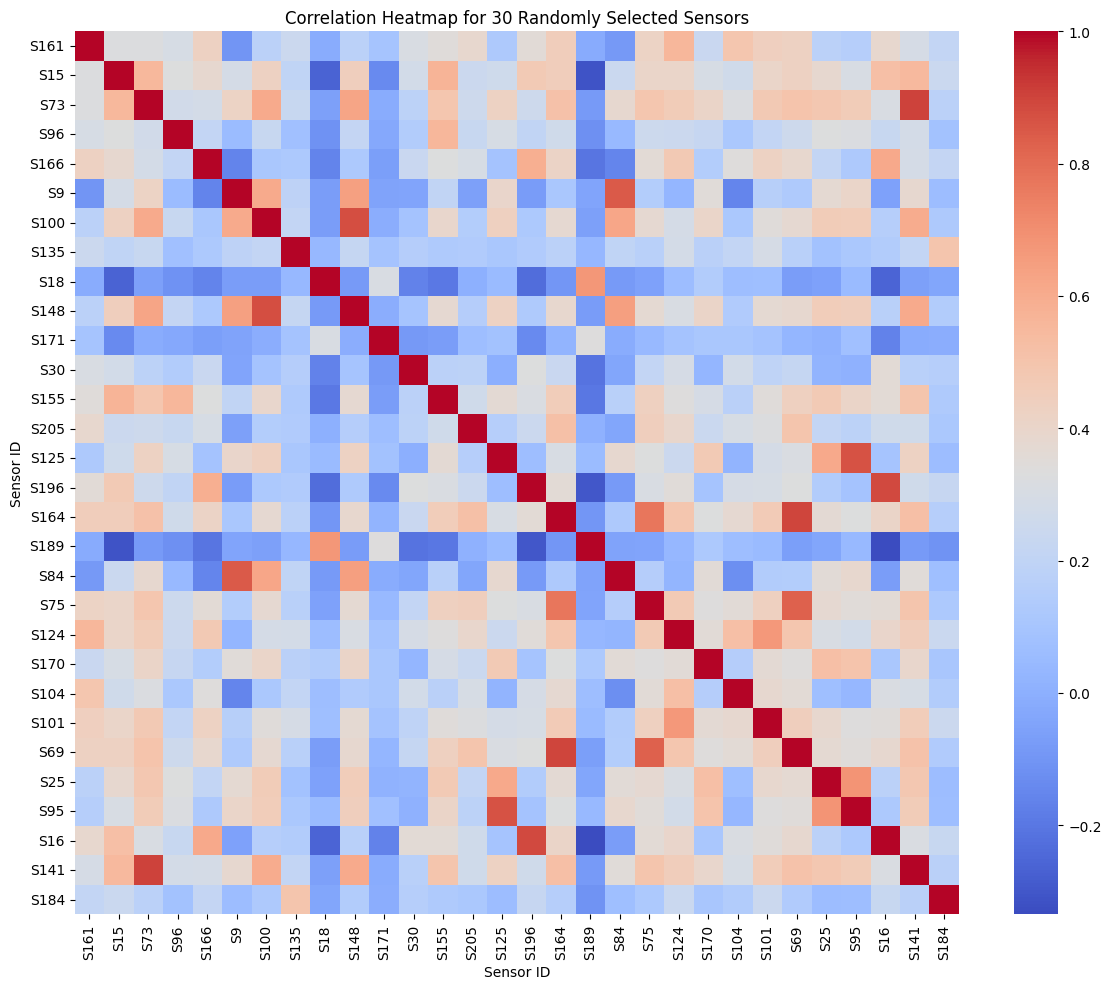

In [162]:
if 'traffic' not in locals():
    print("Please ensure 'traffic' (np array) is loaded.")
else:
    num_sensors_to_correlate = min(traffic.shape[1], 30)
    np.random.seed(42)
    sensor_indices_for_corr = np.random.choice(traffic.shape[1], num_sensors_to_correlate, replace=False)

    subset_traffic = traffic[:, sensor_indices_for_corr]
    correlation_matrix = np.corrcoef(subset_traffic, rowvar=False)

    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f",
                xticklabels=[f'S{i}' for i in sensor_indices_for_corr],
                yticklabels=[f'S{i}' for i in sensor_indices_for_corr])
    plt.title(f'Correlation Heatmap for {num_sensors_to_correlate} Randomly Selected Sensors')
    plt.xlabel('Sensor ID')
    plt.ylabel('Sensor ID')
    plt.tight_layout()
    plt.show()

# **Train / Validation / Test Split**


In [127]:
n = len(traffic)

train_end = int(n * 0.70)
val_end = int(n * 0.80)

train = traffic[:train_end]
val = traffic[train_end:val_end]
test = traffic[val_end:]

print(train.shape)
print(val.shape)
print(test.shape)

(23990, 207)
(3427, 207)
(6855, 207)


# **Standardization**

In [128]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train)

val_scaled = scaler.transform(val)

test_scaled = scaler.transform(test)

#**Create Forecasting Horizons**

5-minute intervals:

Horizon	Steps
15 min	3
30 min	6
45 min	9
60 min	12

In [129]:
HORIZONS = {
    "15min":3,
    "30min":6,
    "45min":9,
    "60min":12
}

INPUT_WINDOW = 12

#**Dataset Builder**

In [152]:
class TrafficDataset(Dataset):

    def __init__(self,data,horizon):
        self.X=[]
        self.y=[]
        for i in range(
            len(data)-INPUT_WINDOW-horizon
        ):
            self.X.append(
                data[i:i+INPUT_WINDOW]
            )
            self.y.append(
                data[i+INPUT_WINDOW+horizon-1]
            )
        self.X=np.array(self.X)
        self.y=np.array(self.y)

    def __len__(self):
        return len(self.X)
    def __getitem__(self,idx):

        return (
            torch.FloatTensor(self.X[idx]),
            torch.FloatTensor(self.y[idx])
        )

#**Metrics**

In [153]:
def evaluate(y_true,y_pred):

    mae = mean_absolute_error(
        y_true.flatten(),
        y_pred.flatten()
    )
    rmse = np.sqrt(
        mean_squared_error(
            y_true.flatten(),
            y_pred.flatten()
        )
    )
    mape = np.mean(
        np.abs(
            (y_true.flatten()-y_pred.flatten())/(y_true.flatten()+1e-5)
        )
    )*100

    return mae,rmse,mape

#**Historical Average Baseline**

In [132]:
def historical_average(train,test):

    mean_speed = train.mean(axis=0)
    preds = np.tile(
        mean_speed,
        (len(test),1)
    )

    return preds

#**GRU Model**

In [133]:
class GRUModel(nn.Module):

    def __init__(self,n_nodes):

        super().__init__()
        self.gru = nn.GRU(
            input_size=n_nodes,
            hidden_size=128,
            batch_first=True
        )
        self.fc = nn.Linear(
            128,
            n_nodes
        )

    def forward(self,x):
        out,_ = self.gru(x)
        out = out[:,-1,:]
        out = self.fc(out)

        return out

#**LSTM Model**

In [134]:
class LSTMModel(nn.Module):

    def __init__(self,n_nodes):

        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_nodes,
            hidden_size=128,
            batch_first=True
        )
        self.fc = nn.Linear(
            128,
            n_nodes
        )

    def forward(self,x):
        out,_ = self.lstm(x)
        out = out[:,-1,:]
        out = self.fc(out)

        return out

# **Graph Convolution Layer**

In [149]:
class GraphConv(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, x, A):
        # x = [batch, nodes]
        # A = [nodes, nodes]
        return torch.matmul(x, A)

#**STGCN (Distance-Based)**

In [150]:
class STGCN(nn.Module):

    def __init__(self,n_nodes,A):

        super().__init__()
        self.A = torch.FloatTensor(A).to(device)
        self.temporal = nn.Conv1d(
            n_nodes,
            n_nodes,
            kernel_size=3,
            padding=1
        )

        self.fc = nn.Linear(
            n_nodes,
            n_nodes
        )

    def forward(self,x):
        B,T,N = x.shape
        spatial=[]
        for t in range(T):
            xt = x[:, t, :]       # [B,N]
            xt = torch.matmul(
                xt,
                self.A
            )
            spatial.append(xt)

        x = torch.stack(
            spatial,
            dim=1
        )
        # [B,T,N] -> [B,N,T]
        x = x.permute(0,2,1)
        x = self.temporal(
            x
        )
        x = x[:,:,-1]
        x = self.fc(x)

        return x

# **Adaptive STGCN**

In [154]:
class AdaptiveSTGCN(nn.Module):

    def __init__(self,n_nodes):

        super().__init__()
        self.node_emb1 = nn.Parameter(
            torch.randn(
                n_nodes,
                10
            )
        )

        self.node_emb2 = nn.Parameter(
            torch.randn(
                10,
                n_nodes
            )
        )

        self.temporal = nn.Conv1d(
            n_nodes,
            n_nodes,
            kernel_size=3,
            padding=1
        )

        self.fc = nn.Linear(
            n_nodes,
            n_nodes
        )

    def forward(self,x):
        A = F.softmax(
            F.relu(
                torch.mm(
                    self.node_emb1,
                    self.node_emb2
                )
            ),
            dim=1
        )

        A = F.softmax(F.relu(A), dim=-1)
        A = A / (A.sum(dim=1, keepdim=True) + 1e-6)

        spatial=[]
        for t in range(
            x.shape[1]
        ):

            spatial.append(
                torch.matmul(
                    x[:,t,:],
                    A
                )
            )

        x = torch.stack(
            spatial,
            dim=1
        )

        # [B,T,N] -> [B,N,T] for Conv1d
        x = x.permute(0,2,1)
        x = self.temporal(x)
        x = x[:,:,-1]
        x = self.fc(x)

        return x

# **Training Function**

In [163]:
import time

def train_model(
    model,
    train_loader,
    val_loader,
    epochs=20
):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    criterion = nn.MSELoss()
    model.to(device)
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X,y in train_loader:
            X=X.to(device)
            y=y.to(device)
            optimizer.zero_grad()
            pred=model(X)
            loss=criterion(
                pred,
                y
            )

            loss.backward()

            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)
                val_pred = model(X_val)
                val_loss += criterion(val_pred, y_val).item()

        print(
            f"Epoch {epoch+1} Train Loss={train_loss/len(train_loader):.4f} Val Loss={val_loss/len(val_loader):.4f}"
        )

    end_time = time.time()
    training_time = end_time - start_time

    return model, training_time

# **Prediction Function**

In [139]:
def predict(model,loader):

    model.eval()
    preds=[]
    actual=[]

    with torch.no_grad():

        for X,y in loader:
            X=X.to(device)
            pred=model(X)
            preds.append(
                pred.cpu().numpy()
            )

            actual.append(
                y.numpy()
            )

    preds=np.concatenate(preds)
    actual=np.concatenate(actual)

    return actual,preds

#**Run All Horizons**

In [164]:
results=[]

for name,h in HORIZONS.items():
    print("\n",name)
    train_ds = TrafficDataset(
        train_scaled,
        h
    )

    val_ds = TrafficDataset(
        val_scaled,
        h
    )

    test_ds = TrafficDataset(
        test_scaled,
        h
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=64,
        shuffle=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=64
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=64
    )

    print("Historical Average")
    ha_pred_scaled = historical_average(train_scaled, test_scaled)

    ha_pred_eval = ha_pred_scaled[:len(test_ds)]

    ha_y_true = np.array([item[1].numpy() for item in test_ds])

    ha_y_true_real = scaler.inverse_transform(ha_y_true)
    ha_pred_real = scaler.inverse_transform(ha_pred_eval)

    mae_ha, rmse_ha, mape_ha = evaluate(ha_y_true_real, ha_pred_real)
    results.append([
        name,
        "HA",
        mae_ha,
        rmse_ha,
        mape_ha,
    ])

    models = {

        "GRU":
        GRUModel(207),

        "LSTM":
        LSTMModel(207),

        "STGCN":
        STGCN(207,adj_mx),

        "Adaptive_STGCN":
        AdaptiveSTGCN(207)
    }

    for model_name,model in models.items():

        print(model_name)

        model, training_time = train_model(
            model,
            train_loader,
            val_loader
        )

        y_true,y_pred = predict(
            model,
            test_loader
        )

        y_true = scaler.inverse_transform(
            y_true
        )

        y_pred = scaler.inverse_transform(
            y_pred
        )

        mae,rmse,mape = evaluate(
            y_true,
            y_pred
        )

        results.append([
            name,
            model_name,
            mae,
            rmse,
            mape,
            training_time
        ])


 15min
Historical Average
GRU
Epoch 1 Train Loss=0.4232 Val Loss=0.3678
Epoch 2 Train Loss=0.3195 Val Loss=0.3438
Epoch 3 Train Loss=0.2993 Val Loss=0.3379
Epoch 4 Train Loss=0.2887 Val Loss=0.3344
Epoch 5 Train Loss=0.2815 Val Loss=0.3340
Epoch 6 Train Loss=0.2762 Val Loss=0.3333
Epoch 7 Train Loss=0.2722 Val Loss=0.3348
Epoch 8 Train Loss=0.2685 Val Loss=0.3361
Epoch 9 Train Loss=0.2653 Val Loss=0.3382
Epoch 10 Train Loss=0.2631 Val Loss=0.3393
Epoch 11 Train Loss=0.2609 Val Loss=0.3407
Epoch 12 Train Loss=0.2589 Val Loss=0.3405
Epoch 13 Train Loss=0.2568 Val Loss=0.3420
Epoch 14 Train Loss=0.2553 Val Loss=0.3467
Epoch 15 Train Loss=0.2537 Val Loss=0.3469
Epoch 16 Train Loss=0.2523 Val Loss=0.3457
Epoch 17 Train Loss=0.2511 Val Loss=0.3485
Epoch 18 Train Loss=0.2498 Val Loss=0.3505
Epoch 19 Train Loss=0.2488 Val Loss=0.3511
Epoch 20 Train Loss=0.2478 Val Loss=0.3544
LSTM
Epoch 1 Train Loss=0.4439 Val Loss=0.3908
Epoch 2 Train Loss=0.3299 Val Loss=0.3638
Epoch 3 Train Loss=0.3044 Val

#**Results Table**

In [165]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Horizon",
        "Model",
        "MAE",
        "RMSE",
        "MAPE",
        "Training Time"
    ]
)

results_df.sort_values(
    ["Horizon","MAE"]
)

,Horizon,Model,MAE,RMSE,MAPE,Training Time
3,15min,STGCN,3.587094,5.794274,9.374293,30.102757
1,15min,GRU,3.814303,6.066865,9.997688,30.115341
2,15min,LSTM,3.930872,6.306647,10.406672,31.299890
4,15min,Adaptive_STGCN,4.751269,7.767514,13.446535,41.500104
0,15min,HA,7.545410,11.795653,24.536968,0.000000
8,30min,STGCN,4.251334,6.890104,11.492604,31.068403
6,30min,GRU,4.545541,7.335607,12.215253,30.047571
7,30min,LSTM,4.549457,7.574874,12.338660,31.670125
9,30min,Adaptive_STGCN,4.954734,8.079024,14.711097,41.272406
5,30min,HA,7.546278,11.797251,24.543650,0.000000


# **MAE Model Comparison**


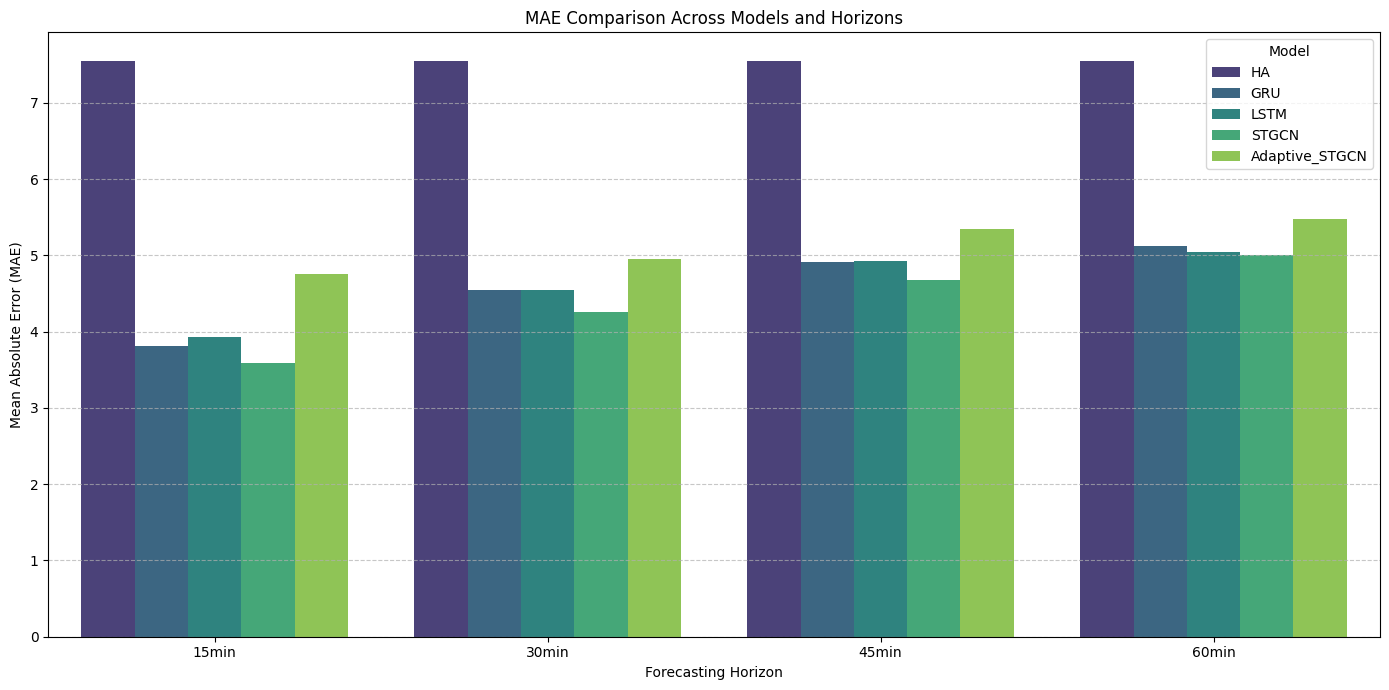

In [166]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Horizon', y='MAE', hue='Model', data=results_df, palette='viridis')
plt.title('MAE Comparison Across Models and Horizons')
plt.xlabel('Forecasting Horizon')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#**RMSE Model Comparison**


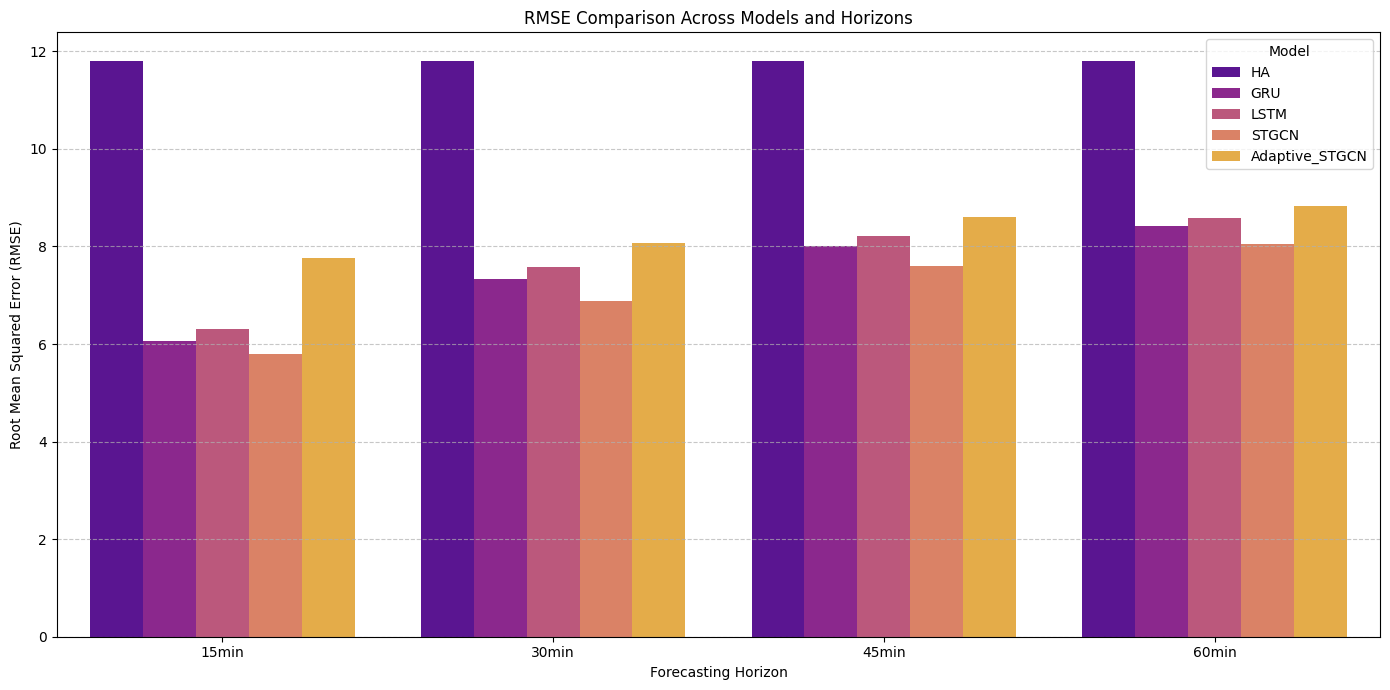

In [167]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Horizon', y='RMSE', hue='Model', data=results_df, palette='plasma')
plt.title('RMSE Comparison Across Models and Horizons')
plt.xlabel('Forecasting Horizon')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#**Horizon MAE Line Graph**

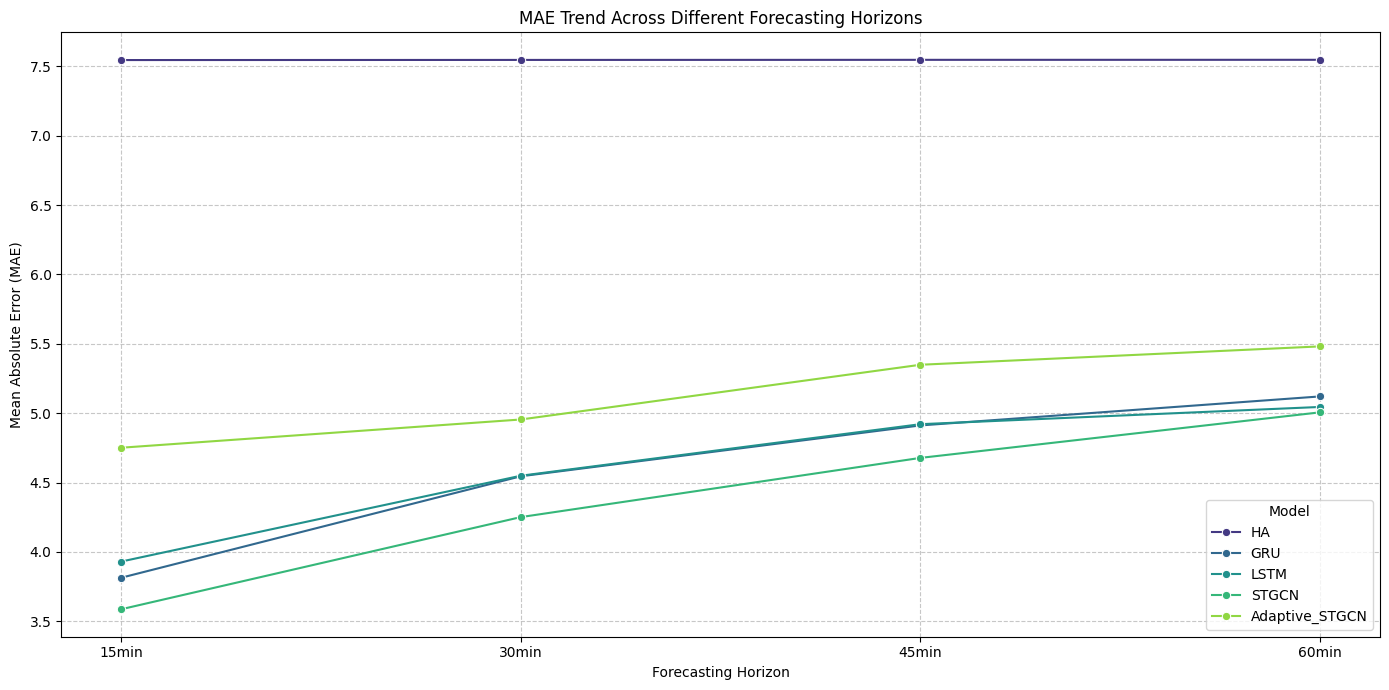

In [168]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='Horizon', y='MAE', hue='Model', data=results_df, marker='o', palette='viridis')
plt.title('MAE Trend Across Different Forecasting Horizons')
plt.xlabel('Forecasting Horizon')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend(title='Model')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#**Training Time Comparison**

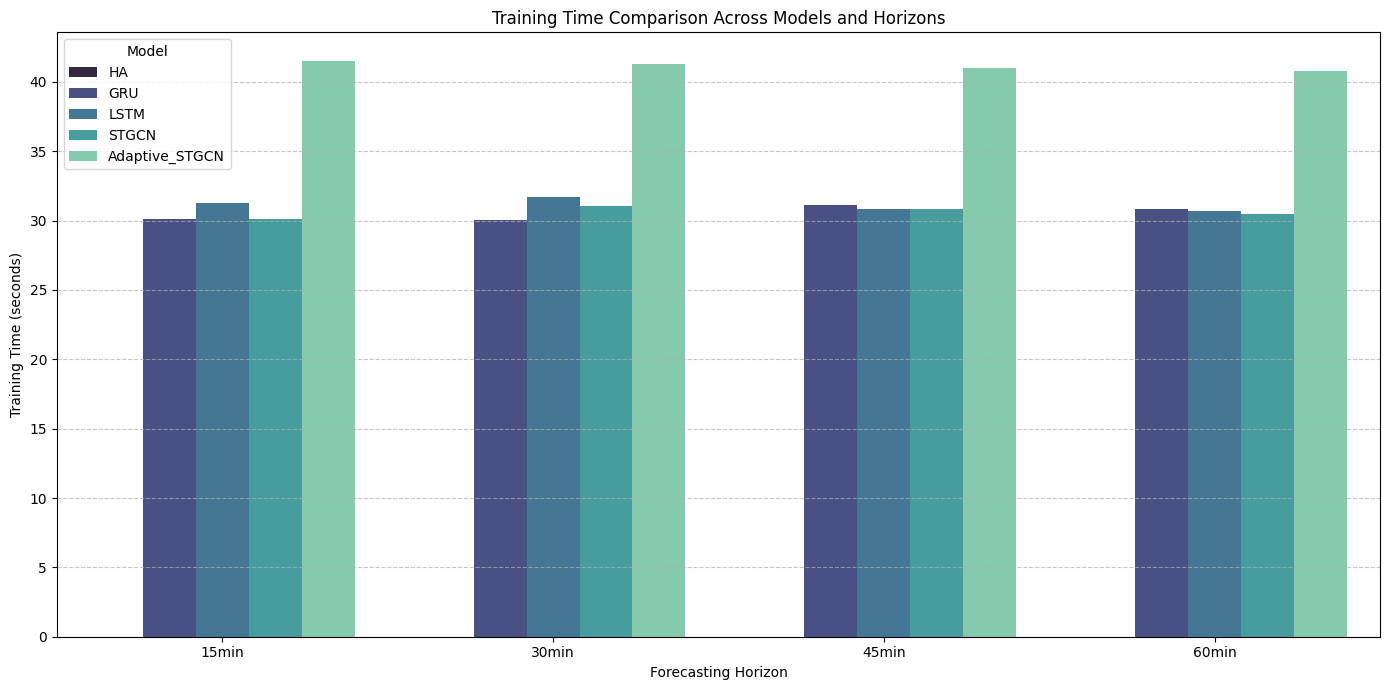

In [169]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Horizon', y='Training Time', hue='Model', data=results_df, palette='mako')
plt.title('Training Time Comparison Across Models and Horizons')
plt.xlabel('Forecasting Horizon')
plt.ylabel('Training Time (seconds)')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#**Accuracy vs Time Trade-off Scatter Plot**

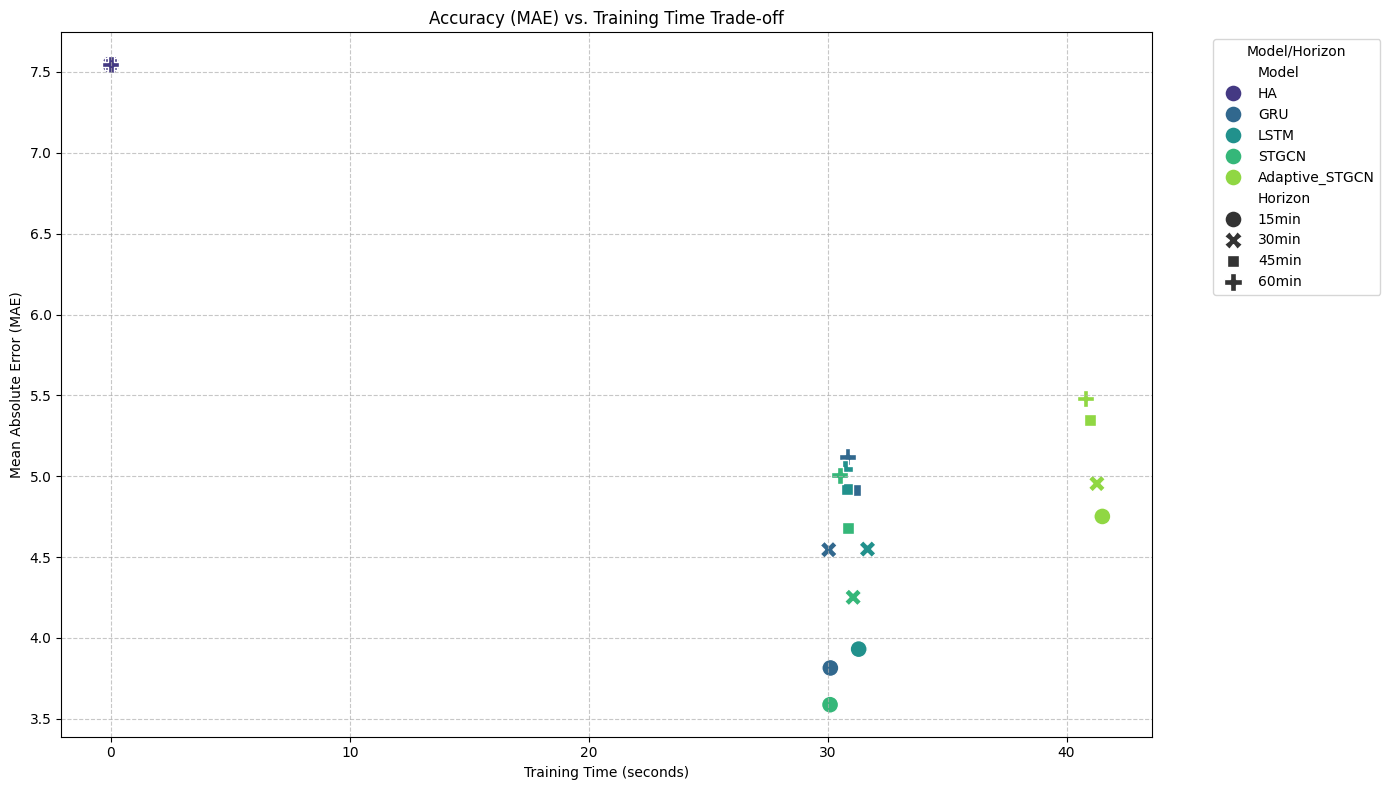

In [170]:
plt.figure(figsize=(14, 8))
sns.scatterplot(x='Training Time', y='MAE', hue='Model', style='Horizon', data=results_df, s=150, palette='viridis')
plt.title('Accuracy (MAE) vs. Training Time Trade-off')
plt.xlabel('Training Time (seconds)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend(title='Model/Horizon', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Distance vs Adaptive Graph Comparison**

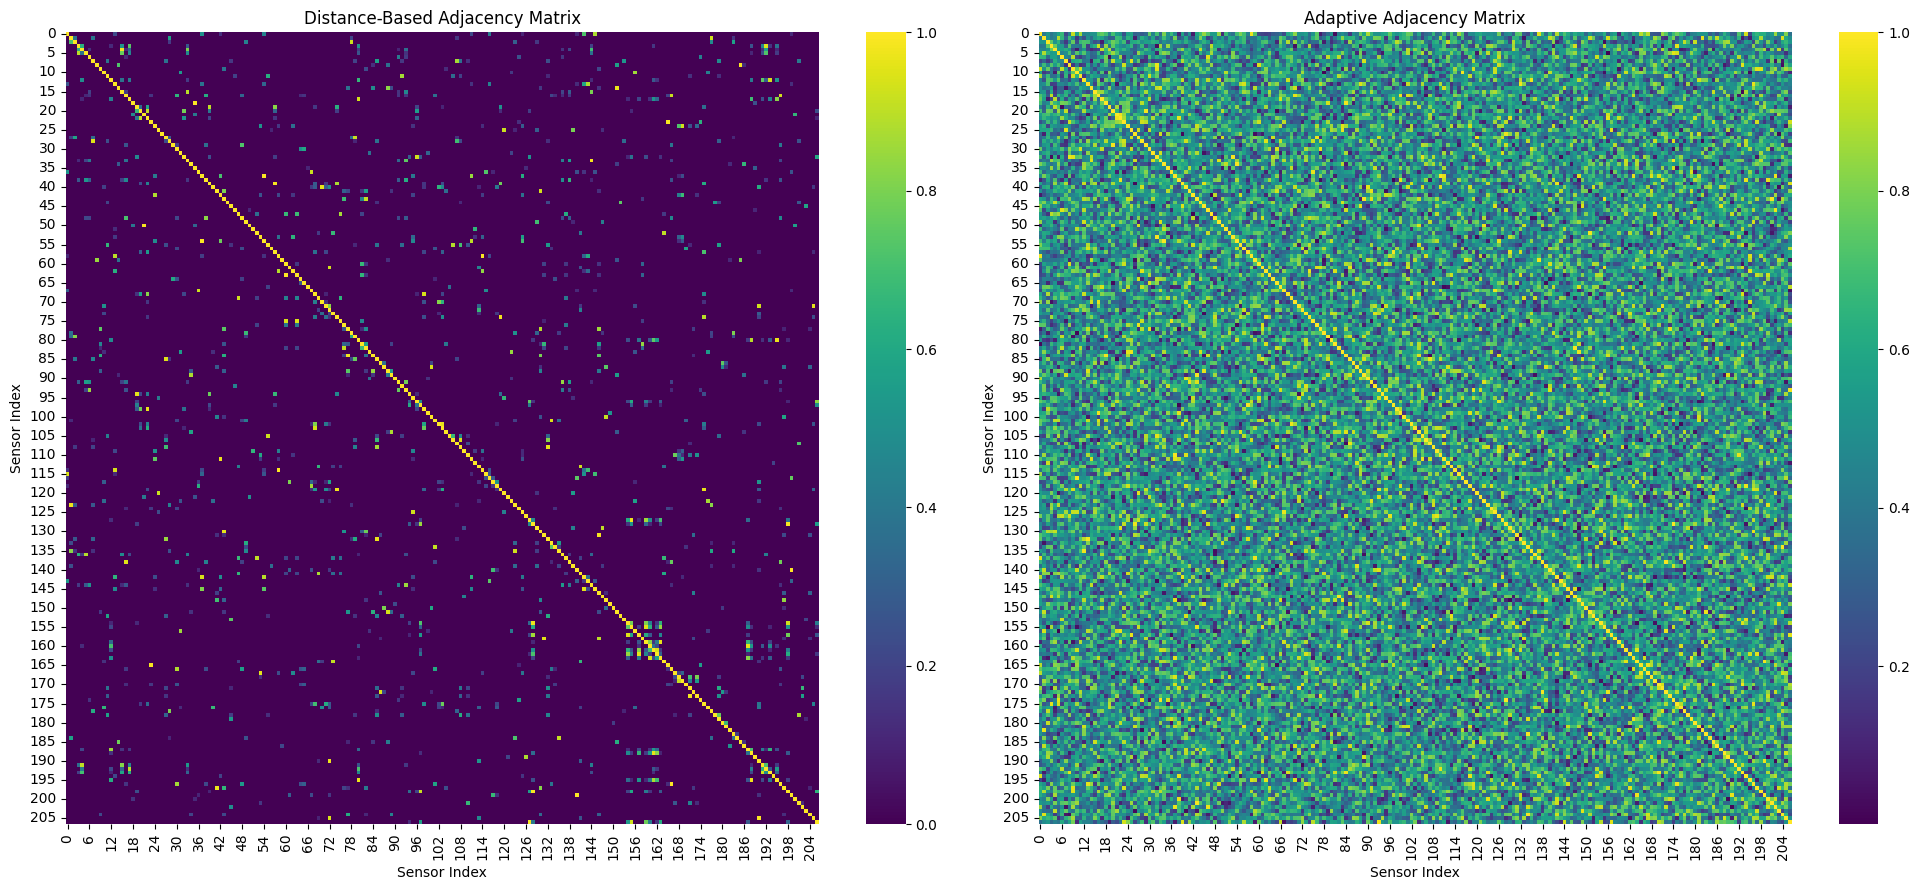

In [171]:
if 'A_distance' in globals() and 'A_adaptive' in globals():
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))

    sns.heatmap(A_distance, cmap='viridis', ax=axes[0], cbar=True)
    axes[0].set_title('Distance-Based Adjacency Matrix')
    axes[0].set_xlabel('Sensor Index')
    axes[0].set_ylabel('Sensor Index')

    sns.heatmap(A_adaptive, cmap='viridis', ax=axes[1], cbar=True)
    axes[1].set_title('Adaptive Adjacency Matrix')
    axes[1].set_xlabel('Sensor Index')
    axes[1].set_ylabel('Sensor Index')

    plt.tight_layout()
    plt.show()
else:
    print("Adjacency matrices (A_distance, A_adaptive) not found in global scope. Please ensure they are defined.")

# **Actual vs Predicted Traffic Speed**

Generating Actual vs Predicted for STGCN at 15min horizon, sensor 0
Re-training STGCN for 15min horizon to get predictions...
Epoch 1 Train Loss=0.4135 Val Loss=0.3709


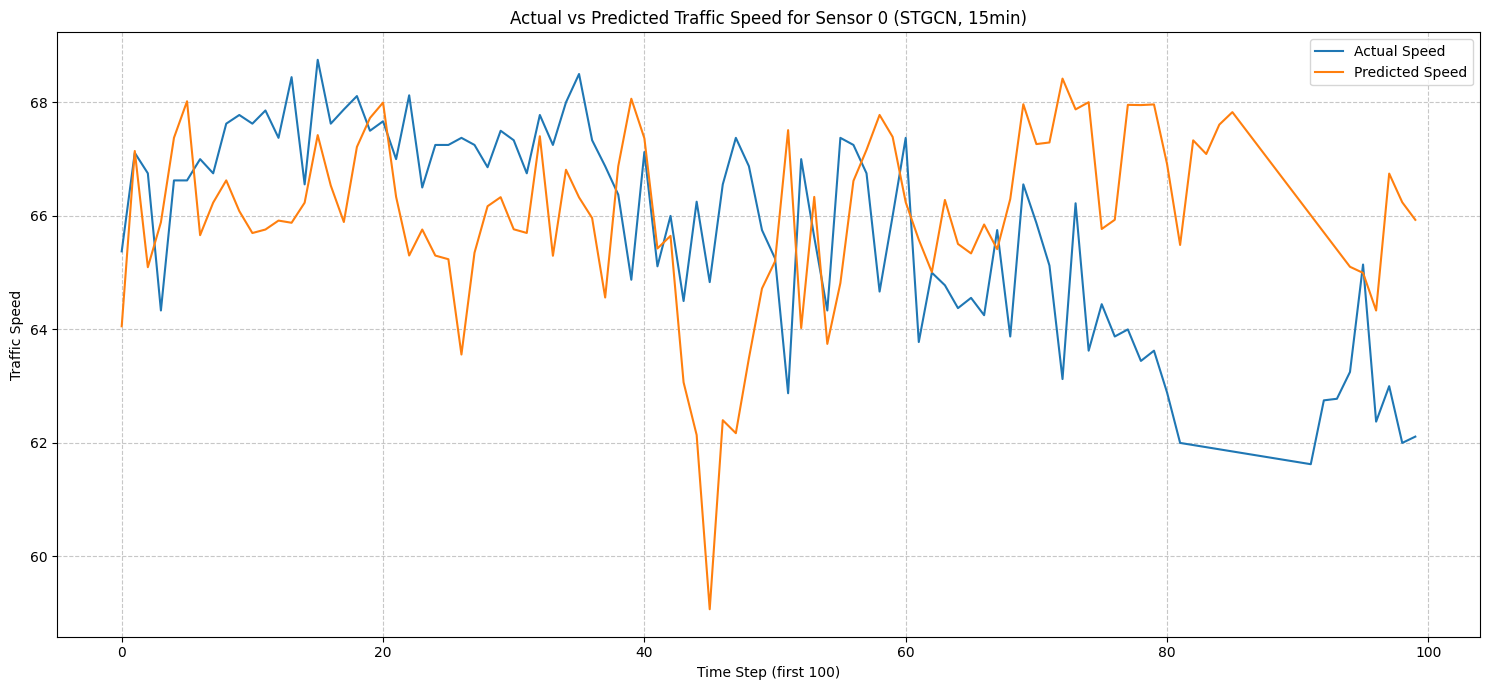

In [172]:
selected_model_name = "STGCN"
selected_horizon = "15min"
example_sensor_idx = 0

h = HORIZONS[selected_horizon]
test_ds = TrafficDataset(test_scaled, h)
test_loader = DataLoader(test_ds, batch_size=64)

print(f"Generating Actual vs Predicted for {selected_model_name} at {selected_horizon} horizon, sensor {example_sensor_idx}")

current_stgcn_model = STGCN(traffic.shape[1], adj_mx).to(device)

print(f"Re-training {selected_model_name} for {selected_horizon} horizon to get predictions...")
train_ds_plot = TrafficDataset(train_scaled, HORIZONS[selected_horizon])
val_ds_plot = TrafficDataset(val_scaled, HORIZONS[selected_horizon])
train_loader_plot = DataLoader(train_ds_plot, batch_size=64, shuffle=True)
val_loader_plot = DataLoader(val_ds_plot, batch_size=64)
test_loader_plot = DataLoader(test_ds, batch_size=64)

model_for_plot = STGCN(traffic.shape[1], adj_mx)
model_for_plot, _ = train_model(model_for_plot, train_loader_plot, val_loader_plot, epochs=1) # Train for 1 epoch for demonstration

y_true_plot, y_pred_plot = predict(model_for_plot, test_loader_plot)

y_true_plot_real = scaler.inverse_transform(y_true_plot)
y_pred_plot_real = scaler.inverse_transform(y_pred_plot)

plt.figure(figsize=(15, 7))
plt.plot(y_true_plot_real[:100, example_sensor_idx], label='Actual Speed')
plt.plot(y_pred_plot_real[:100, example_sensor_idx], label='Predicted Speed')
plt.title(f'Actual vs Predicted Traffic Speed for Sensor {example_sensor_idx} ({selected_model_name}, {selected_horizon})')
plt.xlabel('Time Step (first 100)')
plt.ylabel('Traffic Speed')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#**Export Results**

In [173]:
results_df.to_csv(
    "thesis_results.csv",
    index=False
)

results_df

,Horizon,Model,MAE,RMSE,MAPE,Training Time
0,15min,HA,7.545410,11.795653,24.536968,0.000000
1,15min,GRU,3.814303,6.066865,9.997688,30.115341
2,15min,LSTM,3.930872,6.306647,10.406672,31.299890
3,15min,STGCN,3.587094,5.794274,9.374293,30.102757
4,15min,Adaptive_STGCN,4.751269,7.767514,13.446535,41.500104
5,30min,HA,7.546278,11.797251,24.543650,0.000000
6,30min,GRU,4.545541,7.335607,12.215253,30.047571
7,30min,LSTM,4.549457,7.574874,12.338660,31.670125
8,30min,STGCN,4.251334,6.890104,11.492604,31.068403
9,30min,Adaptive_STGCN,4.954734,8.079024,14.711097,41.272406


# **MAE Comparison Charts**

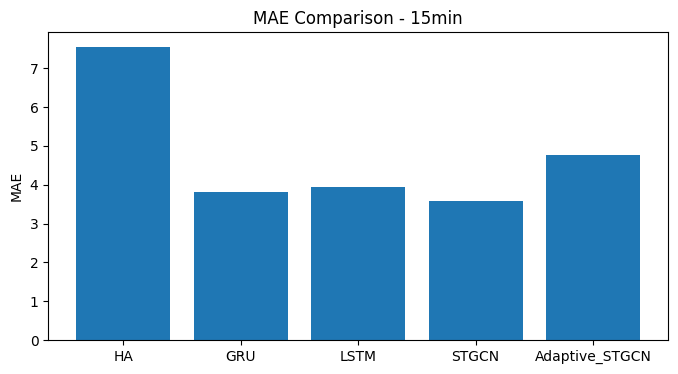

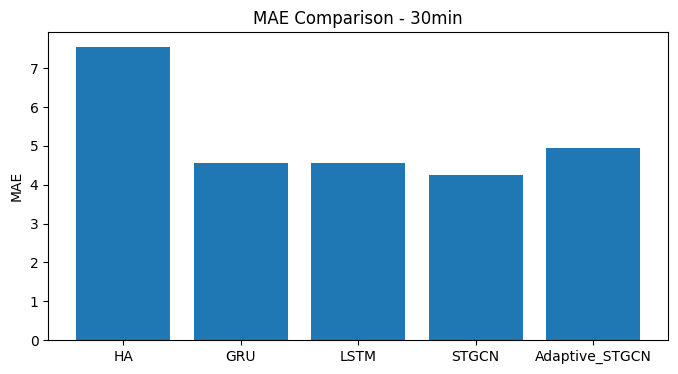

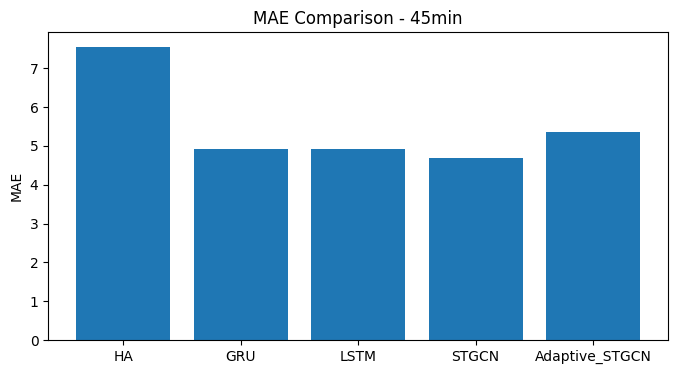

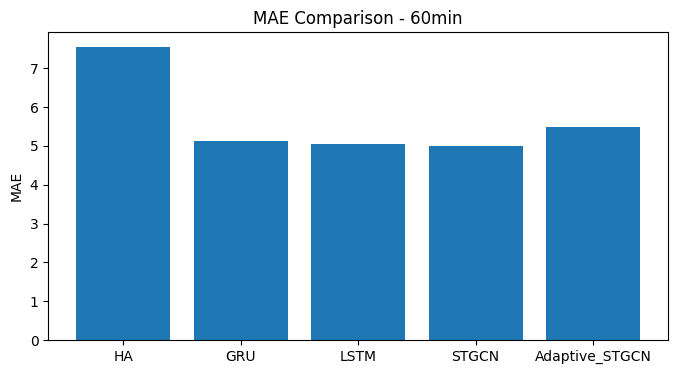

In [175]:
for horizon in results_df.Horizon.unique():

    subset = results_df[
        results_df.Horizon == horizon
    ]
    plt.figure(figsize=(8,4))
    plt.bar(
        subset.Model,
        subset.MAE
    )
    plt.title(
        f"MAE Comparison - {horizon}"
    )
    plt.ylabel("MAE")
    plt.show()